In [1]:
# Machine Learning Forecasting Models

## Objectives

##- Random Forest Regression
## Gradient Boosting Regression
##Forecast Care Load
##ompare Performance

In [2]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

import joblib

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(
    "../data/processed_data.csv"
)

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

In [5]:
df.columns

Index(['Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care', 'HHS_Lag1',
       'HHS_Lag7', 'HHS_Lag14', 'Discharge_Lag1', 'Discharge_Lag7',
       'Discharge_Lag14', 'RollingMean7', 'RollingMean14', 'RollingStd7',
       'RollingStd14', 'NetPressure', 'DayOfWeek', 'Month', 'Quarter',
       'Weekend'],
      dtype='object')

In [6]:
target = 'Children in HHS Care'

In [7]:
X = df.drop(
    columns=['Children in HHS Care']
)

y = df['Children in HHS Care']

In [8]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [9]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(564, 19)
(142, 19)
(564,)
(142,)


In [10]:
#RANDOM FOREST
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

In [11]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [12]:
rf_pred = rf_model.predict(
    X_test
)

In [13]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_mape = np.mean(
    np.abs(
        (y_test-rf_pred)
        /
        y_test
    )
)*100

print("RF MAE:", rf_mae)
print("RF RMSE:", rf_rmse)
print("RF MAPE:", rf_mape)

RF MAE: 66.47809233684929
RF RMSE: 88.56643072432102
RF MAPE: 3.0752318169652697


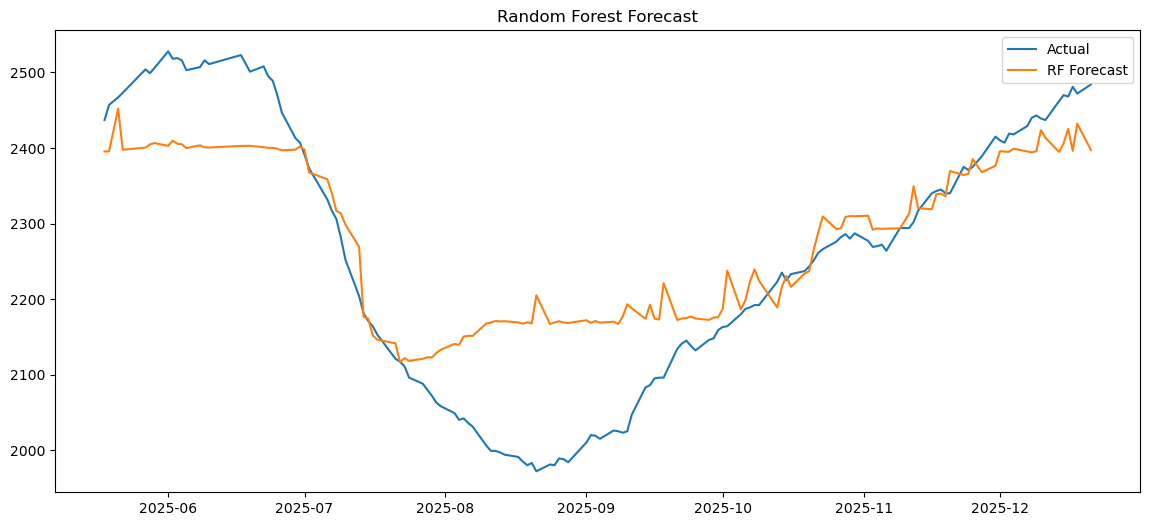

In [14]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.index,
    y_test,
    label='Actual'
)

plt.plot(
    y_test.index,
    rf_pred,
    label='RF Forecast'
)

plt.legend()

plt.title(
    'Random Forest Forecast'
)

plt.show()

In [15]:
joblib.dump(
    rf_model,
    "../models/rf.pkl"
)

['../models/rf.pkl']

In [16]:
#PART B — GRADIENT BOOSTING
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [17]:
gbr_model.fit(
    X_train,
    y_train
)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=200,
                          random_state=42)

In [18]:
gbr_pred = gbr_model.predict(
    X_test
)

In [19]:
gbr_mae = mean_absolute_error(
    y_test,
    gbr_pred
)

gbr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gbr_pred
    )
)

gbr_mape = np.mean(
    np.abs(
        (y_test-gbr_pred)
        /
        y_test
    )
)*100

print("GBR MAE:", gbr_mae)
print("GBR RMSE:", gbr_rmse)
print("GBR MAPE:", gbr_mape)

GBR MAE: 64.44106614110845
GBR RMSE: 86.98802569631621
GBR MAPE: 2.985877069666482


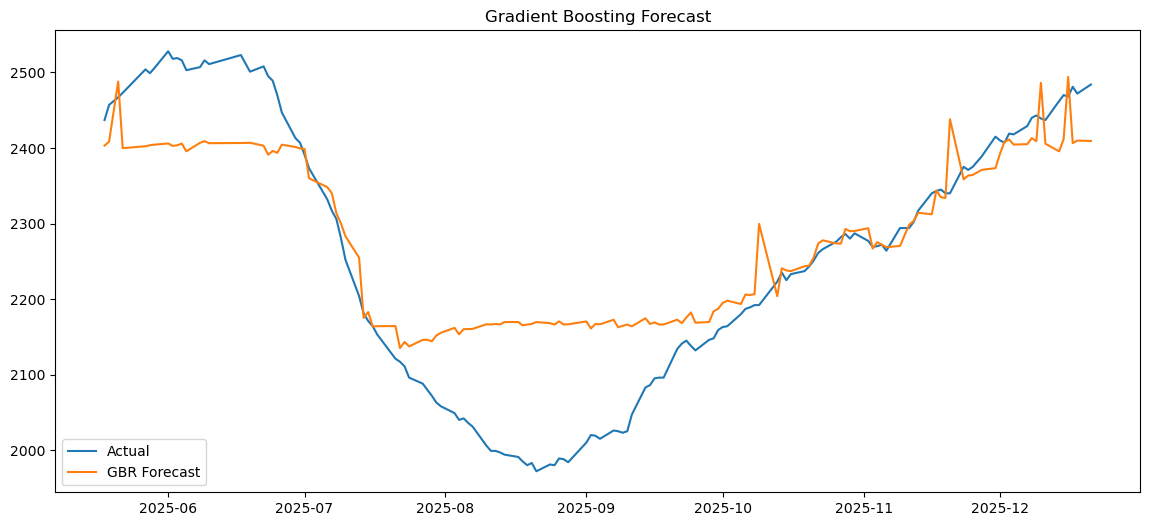

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.index,
    y_test,
    label='Actual'
)

plt.plot(
    y_test.index,
    gbr_pred,
    label='GBR Forecast'
)

plt.legend()

plt.title(
    'Gradient Boosting Forecast'
)

plt.show()

In [21]:
joblib.dump(
    gbr_model,
    "../models/gbr.pkl"
)

['../models/gbr.pkl']

In [22]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
4,HHS_Lag1,0.765185
10,RollingMean7,0.161512
11,RollingMean14,0.036674
5,HHS_Lag7,0.023903
6,HHS_Lag14,0.006737
1,Children in CBP custody,0.001696
0,Children apprehended and placed in CBP custody*,0.000716
16,Month,0.000488
14,NetPressure,0.000444
12,RollingStd7,0.000440


In [23]:
comparison = pd.DataFrame({

'Model':['ARIMA',
         'SARIMA',
         'Random Forest',
         'Gradient Boosting'],

'MAE':[272.55,
       828.41,
       rf_mae,
       gbr_mae],

'RMSE':[323.05,
        921.66,
        rf_rmse,
        gbr_rmse]
})

comparison

,Model,MAE,RMSE
0,ARIMA,272.550000,323.050000
1,SARIMA,828.410000,921.660000
2,Random Forest,66.478092,88.566431
3,Gradient Boosting,64.441066,86.988026
